# Amazon Music OPE: A/B gate

The question here is simple: what happens if an OPE estimate is used to decide whether a ranking policy gets an online experiment?

The gate is a minimum uplift over the logging policy. The benchmark reports intervals for both the target-policy value and the logging-policy value; I combine them into a conservative held-out uplift envelope. Thresholds inside that envelope are left unscored. Only thresholds with a definite held-out PASS or FAIL are used when counting gate errors.


## Prior work

INTERPOL was proposed to trade off two known ranking-OPE failure modes: bias from a misspecified position-based model and the higher variance of an item-position model.

Reference: Buchholz, London, di Benedetto, Joachims (2022), *Off-policy evaluation for learning-to-rank via interpolating the item-position model and the position-based model*, arXiv:2210.09512.

The estimator bias/variance pattern itself is prior work. This notebook only checks how those estimators behave when their output is turned into a fixed pre-A/B gate on the Amazon Music benchmark.


In [1]:
from pathlib import Path
import os
import sys
import time
import math
import shutil
import warnings
import json
import re
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

REPO_DIR = Path("./music-off-policy-evaluation-benchmark").resolve()
CACHE_DIR = Path("./amazon_music_ope_robust").resolve()
CACHE_DIR.mkdir(exist_ok=True)

DATASET_ID = "amazon/music-off-policy-evaluation-benchmark"

# Random samples drawn across the full D1/D2 splits.
N_D1 = 250_000
N_D2 = 200_000

# Main robustness check.
N_BOOTSTRAPS = 30
BOOTSTRAP_N = 100_000
BOOTSTRAP_ESTIMATORS = ["PBM-D", "INTERPOL-3"]

TOP_K = 10
N_SUPPORT_BUCKETS = 5
N_DISTANCE_BUCKETS = 5

N_JOBS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "threading"

OMEGA = 1.018306600302338

KEEP_COLUMNS = [
    "rewards",
    "logging_selected_actions",
    "target_selected_actions",
    "propensities",
]

print("Repository:", REPO_DIR)
print("Cache:", CACHE_DIR)
print("Random sample sizes:", {"D1": N_D1, "D2": N_D2})
print("Bootstrap repeats:", N_BOOTSTRAPS)

Repository: ./music-off-policy-evaluation-benchmark
Cache: ./amazon_music_ope_robust
Random sample sizes: {'D1': 250000, 'D2': 200000}
Bootstrap repeats: 30


In [2]:
if not REPO_DIR.exists():
    raise FileNotFoundError(
        f"Repository not found: {REPO_DIR}\n"
        "Clone https://github.com/amazon-science/music-off-policy-evaluation-benchmark "
        "next to this notebook."
    )

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("Repository path OK.")

Repository path OK.


## 1. Random sample from the full split

Rows are sampled uniformly across the full D1 and D2 Parquet splits using row-group metadata. Only the four columns needed by the selected estimators are read. This avoids prefix sampling without pulling the full dataset to disk.


In [3]:
# Dependencies used only for remote random access.
import requests
import fsspec
import pyarrow as pa
import pyarrow.parquet as pq


def hf_parquet_files(dataset_id, split):
    response = requests.get(
        "https://datasets-server.huggingface.co/parquet",
        params={"dataset": dataset_id},
        timeout=60,
    )
    response.raise_for_status()
    payload = response.json()

    files = [
        x for x in payload["parquet_files"]
        if x["split"] == split
    ]

    if not files:
        raise RuntimeError(
            f"No Parquet files returned for {dataset_id=} {split=}."
        )

    return files


def parquet_row_group_catalog(files):
    rows = []

    for file_idx, item in enumerate(files):
        url = item["url"]

        with fsspec.open(
            url,
            "rb",
            block_size=8 * 1024 * 1024,
            cache_type="readahead",
        ) as f:
            pf = pq.ParquetFile(f)

            for rg in range(pf.num_row_groups):
                meta = pf.metadata.row_group(rg)
                rows.append({
                    "file_idx": file_idx,
                    "url": url,
                    "row_group": rg,
                    "n_rows": meta.num_rows,
                })

    catalog = pd.DataFrame(rows)
    catalog["start"] = catalog["n_rows"].cumsum().shift(fill_value=0)
    catalog["stop"] = catalog["start"] + catalog["n_rows"]

    return catalog


def random_rows_from_remote_split(
    dataset_id,
    split,
    n_rows,
    seed,
    out_path,
):
    out_path = Path(out_path)

    if out_path.exists():
        print("Using cached random sample:", out_path)
        return out_path

    files = hf_parquet_files(dataset_id, split)
    catalog = parquet_row_group_catalog(files)

    total_rows = int(catalog["n_rows"].sum())

    if n_rows > total_rows:
        raise ValueError(
            f"Requested {n_rows:,} rows but split has {total_rows:,}."
        )

    local_rng = np.random.default_rng(seed)

    # Exact uniform sample of global row indices, without replacement.
    global_indices = np.sort(
        local_rng.choice(
            total_rows,
            size=n_rows,
            replace=False,
        )
    )

    # Map each sampled global row to a row group.
    stops = catalog["stop"].to_numpy()
    rg_ids = np.searchsorted(
        stops,
        global_indices,
        side="right",
    )

    selections = {}

    for global_idx, rg_id in zip(global_indices, rg_ids):
        row = catalog.iloc[int(rg_id)]
        key = (
            int(row["file_idx"]),
            int(row["row_group"]),
        )
        local_idx = int(
            global_idx - int(row["start"])
        )
        selections.setdefault(key, []).append(local_idx)

    writer = None
    written = 0
    t0 = time.time()

    try:
        for file_idx, item in enumerate(files):
            wanted = {
                rg: idxs
                for (fidx, rg), idxs in selections.items()
                if fidx == file_idx
            }

            if not wanted:
                continue

            with fsspec.open(
                item["url"],
                "rb",
                block_size=8 * 1024 * 1024,
                cache_type="readahead",
            ) as f:
                pf = pq.ParquetFile(f)

                for rg, local_indices in sorted(wanted.items()):
                    table = pf.read_row_group(
                        rg,
                        columns=KEEP_COLUMNS,
                    )

                    selected = table.take(
                        pa.array(
                            local_indices,
                            type=pa.int64(),
                        )
                    )

                    if writer is None:
                        writer = pq.ParquetWriter(
                            out_path,
                            selected.schema,
                            compression="zstd",
                        )

                    writer.write_table(selected)
                    written += selected.num_rows

                    print(
                        f"{split}: {written:,}/{n_rows:,}",
                        end="\r",
                    )

    finally:
        if writer is not None:
            writer.close()

    if written != n_rows:
        raise RuntimeError(
            f"Expected {n_rows:,} sampled rows, wrote {written:,}."
        )

    print(
        f"\nSaved uniform random sample from all {total_rows:,} {split} rows "
        f"-> {out_path} in {(time.time() - t0):.1f}s"
    )

    return out_path


D1_LOCAL = random_rows_from_remote_split(
    DATASET_ID,
    "D1",
    N_D1,
    SEED + 1,
    CACHE_DIR / f"D1_random_{N_D1}_seed{SEED+1}.parquet",
)

D2_LOCAL = random_rows_from_remote_split(
    DATASET_ID,
    "D2",
    N_D2,
    SEED + 2,
    CACHE_DIR / f"D2_random_{N_D2}_seed{SEED+2}.parquet",
)

for p in [D1_LOCAL, D2_LOCAL]:
    print(p.name, f"{p.stat().st_size / (1024**2):.1f} MB")

Using cached random sample: ./amazon_music_ope_robust/D1_random_250000_seed43.parquet
Using cached random sample: ./amazon_music_ope_robust/D2_random_200000_seed44.parquet
D1_random_250000_seed43.parquet 22.9 MB
D2_random_200000_seed44.parquet 18.5 MB


### Sampling check

The next cell records the seed, sample size, and ranking-length distribution for both samples.


In [4]:
def sample_metadata(path, split, seed):
    pf = pq.ParquetFile(path)

    lengths = []
    for batch in pf.iter_batches(
        columns=["logging_selected_actions"],
        batch_size=4096,
    ):
        lengths.extend(
            len(x)
            for x in batch.column(0).to_pylist()
        )

    return {
        "split": split,
        "seed": seed,
        "n_rows": pf.metadata.num_rows,
        "median_ranking_length": float(np.median(lengths)),
        "p10_ranking_length": float(np.quantile(lengths, 0.10)),
        "p90_ranking_length": float(np.quantile(lengths, 0.90)),
    }


sampling_audit = pd.DataFrame([
    sample_metadata(D1_LOCAL, "D1", SEED + 1),
    sample_metadata(D2_LOCAL, "D2", SEED + 2),
])

sampling_audit

,split,seed,n_rows,median_ranking_length,p10_ranking_length,p90_ranking_length
0,D1,43,250000,50.0,15.0,50.0
1,D2,44,200000,50.0,15.0,50.0


## 2. Reduced-schema compatibility

Amazon's generic `DataBatch` expects the `actions` field. PBM-D, IPM and INTERPOL-3 do not use the 129-dimensional action features on the selected code path, so the notebook keeps only the minimum action-index space needed by the estimators.

The source scan below fails if those estimator implementations start dereferencing action features.


In [5]:
from data.batch import DataBatch

FILES_USED = [
    REPO_DIR / "estimators" / "ground_truth.py",
    REPO_DIR / "estimators" / "pbm.py",
    REPO_DIR / "estimators" / "ipm.py",
    REPO_DIR / "estimators" / "interpol.py",
]

for optional_name in ["base.py", "estimator.py", "ope.py"]:
    p = REPO_DIR / "estimators" / optional_name
    if p.exists():
        FILES_USED.append(p)

action_refs = []
suspicious_imports = []

for p in FILES_USED:
    text = p.read_text(encoding="utf-8")

    for lineno, line in enumerate(text.splitlines(), start=1):
        stripped = line.strip()

        if ".actions" in line:
            action_refs.append(
                (str(p.relative_to(REPO_DIR)), lineno, stripped)
            )

        if stripped.startswith(("from ", "import ")):
            lower = stripped.lower()
            if any(token in lower for token in [
                "reward_model",
                "estimators.dm",
                "estimators.dr",
                "dr_ranking",
            ]):
                suspicious_imports.append(
                    (str(p.relative_to(REPO_DIR)), lineno, stripped)
                )

if action_refs or suspicious_imports:
    for hit in action_refs + suspicious_imports:
        print(hit)
    raise RuntimeError(
        "Selected estimator path appears to require action features. "
        "Reduced-schema patch is unsafe."
    )


def _from_record_low_disk(batch):
    d = batch.to_pydict()
    placeholder_actions = []

    for logging_ids, target_ids in zip(
        d["logging_selected_actions"],
        d["target_selected_actions"],
    ):
        ids = list(logging_ids) + list(target_ids)
        min_required_L = (max(ids) + 1) if ids else 0
        placeholder_actions.append(range(min_required_L))

    return DataBatch(
        actions=d.get("actions", placeholder_actions),
        rewards=d["rewards"],
        logging_actions=d["logging_selected_actions"],
        target_actions=d["target_selected_actions"],
        propensities=d["propensities"],
        n_rows=batch.num_rows,
    )


DataBatch.from_record = staticmethod(_from_record_low_disk)

print("Reduced-schema patch applied.")

Reduced-schema patch applied.


## 3. Reported intervals

The benchmark estimators return lower and upper bounds. The next cell inspects the checked-out Amazon source for how those bounds are constructed.

Throughout the notebook I keep the neutral wording **reported interval** unless the benchmark code itself establishes a specific confidence level and construction.


In [6]:
CI_PATTERNS = [
    r"ConfidenceInterval",
    r"lower_bound",
    r"upper_bound",
    r"percentile",
    r"quantile",
    r"bootstrap",
    r"1\.96",
    r"norm\.ppf",
    r"sem\(",
    r"std",
]

ci_hits = []

for p in REPO_DIR.rglob("*.py"):
    text = p.read_text(
        encoding="utf-8",
        errors="ignore",
    )

    for lineno, line in enumerate(
        text.splitlines(),
        start=1,
    ):
        if any(
            re.search(pattern, line, re.IGNORECASE)
            for pattern in CI_PATTERNS
        ):
            ci_hits.append({
                "file": str(p.relative_to(REPO_DIR)),
                "line": lineno,
                "source": line.strip(),
            })

ci_audit = pd.DataFrame(ci_hits)

# Keep the display focused on lines that can actually reveal construction.
focus = ci_audit[
    ci_audit["source"].str.contains(
        "ConfidenceInterval|lower_bound|upper_bound|percentile|quantile|bootstrap|1.96|norm.ppf",
        case=False,
        regex=True,
    )
].copy()

pd.set_option("display.max_colwidth", 160)
focus.head(100)

,file,line,source
0,metrics/error_decomposition.py,3,from metrics.confidence_intervals import ConfidenceInterval
1,metrics/error_decomposition.py,11,ci: ConfidenceInterval
2,metrics/error_decomposition.py,14,"return f""bias^22={self.bias2}, var={self.var}, mse={self.mse} ({self.ci.lower_bound}, {self.ci.upper_bound})"""
3,metrics/results.py,4,from metrics.confidence_intervals import ConfidenceInterval
4,metrics/results.py,11,ci: ConfidenceInterval
5,metrics/results.py,17,"f""{self.metric} ({self.ci.lower_bound}, {self.ci.upper_bound}) n={self.n}"""
6,metrics/confidence_intervals.py,6,"ConfidenceInterval = namedtuple(""ConfidenceInterval"", [""lower_bound"", ""upper_bound""])"
7,metrics/confidence_intervals.py,9,def compute_bootstrap_estimates(
8,metrics/confidence_intervals.py,11,"bootstraps: int = 1_000,"
9,metrics/confidence_intervals.py,15,Computes M bootstrap estimates from a dataset of N values.


## 4. Policy distance

Top-10 overlap misses pure reordering, so the notebook also uses normalized Spearman footrule distance over the capped ranking. It is 0 for identical rankings and increases as the ordering changes.


In [7]:
def normalized_footrule(logging_actions, target_actions):
    logging_actions = [int(x) for x in logging_actions]
    target_actions = [int(x) for x in target_actions]

    d = min(len(logging_actions), len(target_actions))

    if d <= 1:
        return 0.0

    logging_actions = logging_actions[:d]
    target_actions = target_actions[:d]

    pos_log = {
        action: i
        for i, action in enumerate(logging_actions)
    }
    pos_target = {
        action: i
        for i, action in enumerate(target_actions)
    }

    # Both are permutations of the same capped action set in this benchmark.
    common = set(pos_log).intersection(pos_target)

    if len(common) != d:
        # Defensive fallback if future schema changes.
        all_items = set(pos_log).union(pos_target)
        missing_rank = d
        raw = sum(
            abs(
                pos_log.get(a, missing_rank)
                - pos_target.get(a, missing_rank)
            )
            for a in all_items
        )
    else:
        raw = sum(
            abs(pos_log[a] - pos_target[a])
            for a in common
        )

    # Maximum Spearman footrule distance between two permutations of length d.
    max_distance = (d * d) // 2

    return float(raw / max(max_distance, 1))


def row_diagnostics(
    logging_actions,
    target_actions,
    propensities,
    top_k=10,
):
    logging_actions = [int(x) for x in logging_actions]
    target_actions = [int(x) for x in target_actions]

    d = min(len(logging_actions), len(target_actions))

    if d == 0:
        return {
            "top10_set_shift": np.nan,
            "rank_footrule": np.nan,
            "support_stress": np.nan,
        }

    logging_actions = logging_actions[:d]
    target_actions = target_actions[:d]

    k = min(top_k, d)

    set_overlap = (
        len(
            set(logging_actions[:k])
            .intersection(target_actions[:k])
        )
        / max(k, 1)
    )

    footrule = normalized_footrule(
        logging_actions,
        target_actions,
    )

    # Propensity matrix rows are in logging-ranking order,
    # columns are positions.
    pos_logging = {
        action: i
        for i, action in enumerate(logging_actions)
    }

    P = np.asarray(propensities, dtype=float)
    probs = []

    max_j = min(d, P.shape[1])

    for j in range(max_j):
        action = target_actions[j]
        i = pos_logging.get(action)

        if i is not None and i < P.shape[0]:
            probs.append(P[i, j])

    if probs:
        probs = np.clip(
            np.asarray(probs, dtype=float),
            1e-12,
            1.0,
        )
        support_stress = float(
            -np.mean(np.log(probs))
        )
    else:
        support_stress = np.nan

    return {
        "top10_set_shift": float(1.0 - set_overlap),
        "rank_footrule": footrule,
        "support_stress": support_stress,
    }


def scan_diagnostics(parquet_path):
    pf = pq.ParquetFile(parquet_path)
    rows = []

    for batch in pf.iter_batches(
        columns=[
            "logging_selected_actions",
            "target_selected_actions",
            "propensities",
        ],
        batch_size=2048,
    ):
        d = batch.to_pydict()

        rows.extend(
            row_diagnostics(log_ids, target_ids, prop)
            for log_ids, target_ids, prop in zip(
                d["logging_selected_actions"],
                d["target_selected_actions"],
                d["propensities"],
            )
        )

    return pd.DataFrame(rows)


diag_d1 = scan_diagnostics(D1_LOCAL)
diag_d2 = scan_diagnostics(D2_LOCAL)

diag_d2.describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)

,top10_set_shift,rank_footrule,support_stress
count,200000.000000,200000.000000,200000.000000
mean,0.214287,0.294976,6.671968
std,0.154107,0.148307,1.490591
min,0.000000,0.000000,0.020203
10%,0.000000,0.139200,4.749527
25%,0.100000,0.193333,6.283325
50%,0.200000,0.268800,7.117007
75%,0.300000,0.366667,7.608197
90%,0.400000,0.481600,7.949306
max,1.000000,1.836800,9.082507


In [8]:
# Sanity check: the rank-sensitive metric must detect pure reversals.
assert normalized_footrule(
    [0, 1, 2, 3, 4],
    [4, 3, 2, 1, 0],
) > 0.9

assert normalized_footrule(
    [0, 1, 2, 3, 4],
    [0, 1, 2, 3, 4],
) == 0.0

print("Rank-distance sanity checks passed.")

Rank-distance sanity checks passed.


## 5. Matched D1/D2 strata

Bucket boundaries are learned from D2 diagnostics and then frozen for D1. Rewards are not used to define the strata.

The notebook uses quintiles of rank-sensitive distance and quintiles of support stress. These slices overlap and should not be read as independent experiments.


In [9]:
def quantile_edges(series, n_buckets):
    edges = (
        series
        .dropna()
        .quantile(
            np.linspace(0, 1, n_buckets + 1)
        )
        .to_numpy(copy=True)
    )

    edges[0] = -np.inf
    edges[-1] = np.inf
    return np.unique(edges)


rank_edges = quantile_edges(
    diag_d2["rank_footrule"],
    N_DISTANCE_BUCKETS,
)

support_edges = quantile_edges(
    diag_d2["support_stress"],
    N_SUPPORT_BUCKETS,
)

rank_labels = [
    f"rank_q{i+1}"
    for i in range(len(rank_edges) - 1)
]

support_labels = [
    f"support_q{i+1}"
    for i in range(len(support_edges) - 1)
]


for diag in [diag_d1, diag_d2]:
    diag["rank_bucket"] = pd.cut(
        diag["rank_footrule"],
        bins=rank_edges,
        labels=rank_labels,
        include_lowest=True,
    )

    diag["support_bucket"] = pd.cut(
        diag["support_stress"],
        bins=support_edges,
        labels=support_labels,
        include_lowest=True,
    )


def summarize_diag(diag, split):
    out = []

    for kind, col in [
        ("rank", "rank_bucket"),
        ("support", "support_bucket"),
    ]:
        for bucket, g in diag.groupby(col, observed=True):
            out.append({
                "split": split,
                "kind": kind,
                "bucket": str(bucket),
                "n": len(g),
                "mean_rank_footrule": g["rank_footrule"].mean(),
                "mean_top10_set_shift": g["top10_set_shift"].mean(),
                "mean_support_stress": g["support_stress"].mean(),
            })

    return pd.DataFrame(out)


strata_summary = pd.concat(
    [
        summarize_diag(diag_d1, "D1"),
        summarize_diag(diag_d2, "D2"),
    ],
    ignore_index=True,
)

strata_summary

,split,kind,bucket,n,mean_rank_footrule,mean_top10_set_shift,mean_support_stress
0,D1,rank,rank_q1,49797,0.128861,0.107400,5.220150
1,D1,rank,rank_q2,49923,0.208499,0.185303,6.600319
2,D1,rank,rank_q3,50517,0.270211,0.222624,6.975079
3,D1,rank,rank_q4,49730,0.345746,0.255389,7.244821
4,D1,rank,rank_q5,50033,0.521731,0.300652,7.333718
5,D1,support,support_q1,49730,0.224800,0.075767,4.244307
6,D1,support,support_q2,50365,0.223710,0.193752,6.496169
7,D1,support,support_q3,49158,0.282034,0.234336,7.111810
8,D1,support,support_q4,50266,0.335284,0.261590,7.514194
9,D1,support,support_q5,50481,0.408265,0.304938,7.992487


In [10]:
STRATA_ROOT = CACHE_DIR / "strata"

if STRATA_ROOT.exists():
    shutil.rmtree(STRATA_ROOT)


def materialize_buckets(source_path, labels, kind, split):
    out_dir = STRATA_ROOT / kind / split
    out_dir.mkdir(parents=True, exist_ok=True)

    labels = pd.Series(labels).astype("string")
    unique_labels = [
        x for x in labels.dropna().unique()
    ]

    paths = {
        label: out_dir / f"{label}.parquet"
        for label in unique_labels
    }

    writers = {}

    try:
        pf = pq.ParquetFile(source_path)
        cursor = 0

        for batch in pf.iter_batches(
            columns=KEEP_COLUMNS,
            batch_size=2048,
        ):
            batch_labels = labels.iloc[
                cursor: cursor + batch.num_rows
            ].to_numpy()

            cursor += batch.num_rows

            for label in unique_labels:
                idx = np.flatnonzero(
                    batch_labels == label
                )

                if not len(idx):
                    continue

                subset = batch.take(
                    pa.array(idx, type=pa.int64())
                )

                if label not in writers:
                    writers[label] = pq.ParquetWriter(
                        paths[label],
                        subset.schema,
                        compression="zstd",
                    )

                writers[label].write_batch(subset)

    finally:
        for writer in writers.values():
            writer.close()

    return paths


rank_paths = {
    "D1": materialize_buckets(
        D1_LOCAL,
        diag_d1["rank_bucket"],
        "rank",
        "D1",
    ),
    "D2": materialize_buckets(
        D2_LOCAL,
        diag_d2["rank_bucket"],
        "rank",
        "D2",
    ),
}

support_paths = {
    "D1": materialize_buckets(
        D1_LOCAL,
        diag_d1["support_bucket"],
        "support",
        "D1",
    ),
    "D2": materialize_buckets(
        D2_LOCAL,
        diag_d2["support_bucket"],
        "support",
        "D2",
    ),
}

print("Materialized matched strata.")

Materialized matched strata.


## 6. Ground truth and estimators

D1 is used for held-out target-policy references and D2 for OPE, following the benchmark setup.


In [11]:
from estimators.ground_truth import GroundTruth
from estimators.ipm import IPM
from estimators.pbm import PBM, PBMType
from estimators.interpol import INTERPOL

PB = np.array([
    1.0,
    0.76674848,
    0.33742719,
    0.26136553,
    0.20732642,
    0.16384161,
    0.13263467,
    0.11458964,
    0.11255035,
    0.09426026,
    0.07283572,
    0.07004059,
    0.06315475,
    0.05890552,
    0.05496263,
])


def make_estimators():
    return {
        "PBM-D": PBM(
            position_bias=PB,
            type=PBMType.DETERMINISTIC,
        ),
        "IPM": IPM(),
        "INTERPOL-3": INTERPOL(
            window_size=3,
            position_bias=PB,
        ),
    }


def unpack_estimate(obj):
    return {
        "metric": float(obj.metric),
        "lower": float(obj.ci.lower_bound),
        "upper": float(obj.ci.upper_bound),
        "n": int(obj.n),
    }


overall_gt_obj = GroundTruth(
    omega=OMEGA
).evaluate(str(D1_LOCAL))

overall_gt = unpack_estimate(overall_gt_obj)

print("Held-out D1 target-policy reference:")
print(overall_gt_obj)

Held-out D1 target-policy reference:
1.2594986284235485 (1.2557306903411098, 1.2630914177707353) n=250000


In [12]:
def evaluate_estimator(
    name,
    estimator,
    d2_path,
    gt_obj,
    random_seed=None,
):
    # Amazon's reported intervals use numpy's global RNG internally.
    # Seed each call explicitly so interval-dependent gate results are reproducible.
    if random_seed is not None:
        np.random.seed(int(random_seed))

    est_name, estimate, err = estimator.benchmark(
        name,
        str(d2_path),
        gt_obj,
        None,
    )

    gt = float(gt_obj.metric)
    est = float(estimate.metric)
    lower = float(estimate.ci.lower_bound)
    upper = float(estimate.ci.upper_bound)

    return {
        "estimator": est_name,
        "ground_truth": gt,
        "estimate": est,
        "signed_error": est - gt,
        "absolute_error": abs(est - gt),
        "relative_abs_error": abs(est - gt) / max(abs(gt), 1e-12),
        "reported_lower": lower,
        "reported_upper": upper,
        "reported_interval_width": upper - lower,
        "reported_interval_contains_gt_point": lower <= gt <= upper,
        "bias2": float(err.bias2),
        "variance": float(err.var),
        "mse": float(err.mse),
    }


baseline_rows = []
for idx, (name, estimator) in enumerate(make_estimators().items()):
    baseline_rows.append(
        evaluate_estimator(
            name,
            estimator,
            D2_LOCAL,
            overall_gt_obj,
            random_seed=SEED + 1_000 + idx,
        )
    )

baseline = pd.DataFrame(baseline_rows)

baseline.sort_values("mse")

,estimator,ground_truth,estimate,signed_error,absolute_error,relative_abs_error,reported_lower,reported_upper,reported_interval_width,reported_interval_contains_gt_point,bias2,variance,mse
2,INTERPOL-3,1.259499,1.292150,0.032651,0.032651,0.025924,1.231959,1.347977,0.116018,True,0.001066,0.000853,0.001918
0,PBM-D,1.259499,1.314705,0.055206,0.055206,0.043832,1.307457,1.322130,0.014673,False,0.003052,0.000014,0.003066
1,IPM,1.259499,1.361480,0.101981,0.101981,0.080969,1.138441,1.576594,0.438153,True,0.009564,0.012241,0.021805


## 7. Slice analysis

Each slice gets its own held-out D1 reference and is evaluated on the matching D2 slice. The slices are overlapping views of the same sampled splits, not independent replications.


In [13]:
def slice_results(kind, d1_paths, d2_paths):
    rows = []

    for bucket_idx, (bucket, d2_path) in enumerate(d2_paths.items()):
        d1_path = d1_paths[bucket]

        gt_obj = GroundTruth(
            omega=OMEGA
        ).evaluate(str(d1_path))

        for estimator_idx, (name, estimator) in enumerate(make_estimators().items()):
            row = evaluate_estimator(
                name,
                estimator,
                d2_path,
                gt_obj,
                random_seed=(
                    SEED
                    + 10_000
                    + 100 * bucket_idx
                    + estimator_idx
                ),
            )

            row.update({
                "kind": kind,
                "bucket": bucket,
            })

            rows.append(row)

    return pd.DataFrame(rows)


slices = pd.concat(
    [
        slice_results(
            "rank",
            rank_paths["D1"],
            rank_paths["D2"],
        ),
        slice_results(
            "support",
            support_paths["D1"],
            support_paths["D2"],
        ),
    ],
    ignore_index=True,
)

slice_meta = strata_summary[
    strata_summary["split"] == "D2"
].drop(columns=["split"])

slices = slices.merge(
    slice_meta,
    on=["kind", "bucket"],
    how="left",
)

slices.head()

,estimator,ground_truth,estimate,signed_error,absolute_error,relative_abs_error,reported_lower,reported_upper,reported_interval_width,reported_interval_contains_gt_point,bias2,variance,mse,kind,bucket,n,mean_rank_footrule,mean_top10_set_shift,mean_support_stress
0,PBM-D,1.321745,1.395919,0.074174,0.074174,0.056118,1.373913,1.417160,0.043246,False,0.005602,0.000123,0.005725,rank,rank_q5,39913,0.522682,0.299870,7.330089
1,IPM,1.321745,1.381193,0.059448,0.059448,0.044977,0.807304,1.851139,1.043835,True,0.004098,0.067232,0.071330,rank,rank_q5,39913,0.522682,0.299870,7.330089
2,INTERPOL-3,1.321745,1.349626,0.027881,0.027881,0.021094,1.163962,1.512443,0.348480,True,0.000708,0.007799,0.008506,rank,rank_q5,39913,0.522682,0.299870,7.330089
3,PBM-D,1.283378,1.352448,0.069071,0.069071,0.053819,1.334366,1.369849,0.035482,False,0.004751,0.000086,0.004837,rank,rank_q4,39817,0.345790,0.257189,7.248852
4,IPM,1.283378,1.327835,0.044457,0.044457,0.034641,0.693784,1.813708,1.119924,True,0.003215,0.084023,0.087239,rank,rank_q4,39817,0.345790,0.257189,7.248852


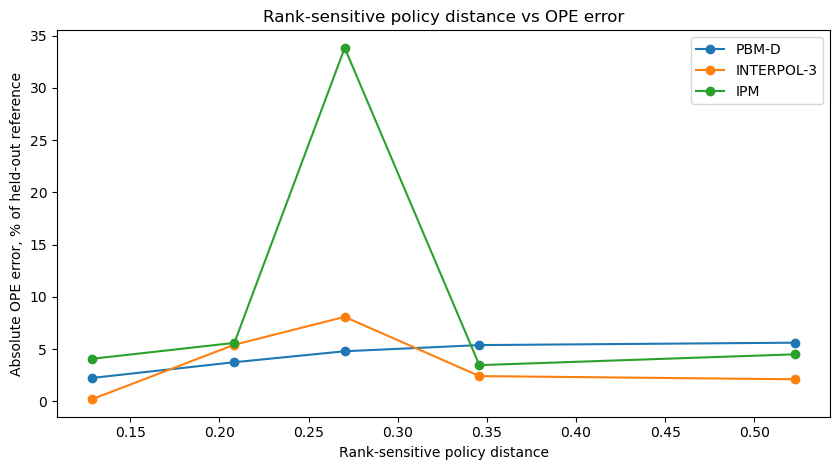

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

rank_result = slices[
    slices["kind"] == "rank"
]

for estimator in ["PBM-D", "INTERPOL-3", "IPM"]:
    g = (
        rank_result[
            rank_result["estimator"] == estimator
        ]
        .sort_values("mean_rank_footrule")
    )

    ax.plot(
        g["mean_rank_footrule"],
        g["relative_abs_error"] * 100,
        marker="o",
        label=estimator,
    )

ax.set_xlabel("Rank-sensitive policy distance")
ax.set_ylabel("Absolute OPE error, % of held-out reference")
ax.set_title("Rank-sensitive policy distance vs OPE error")
ax.legend()
fig.tight_layout()
plt.show()

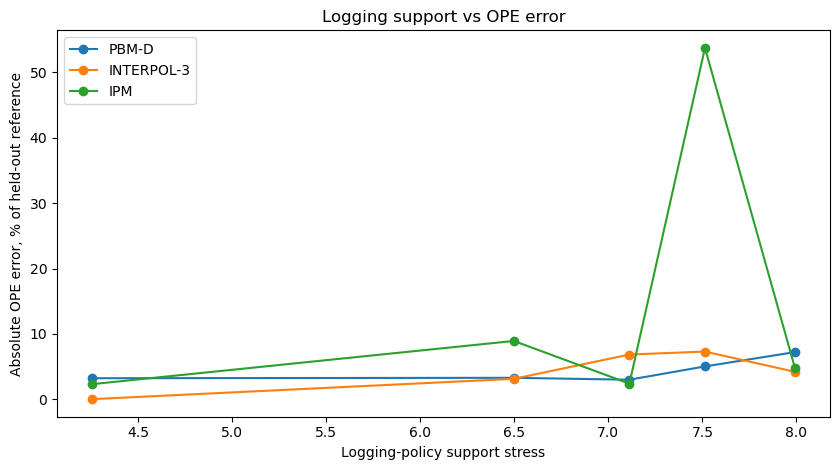

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

support_result = slices[
    slices["kind"] == "support"
]

for estimator in ["PBM-D", "INTERPOL-3", "IPM"]:
    g = (
        support_result[
            support_result["estimator"] == estimator
        ]
        .sort_values("mean_support_stress")
    )

    ax.plot(
        g["mean_support_stress"],
        g["relative_abs_error"] * 100,
        marker="o",
        label=estimator,
    )

ax.set_xlabel("Logging-policy support stress")
ax.set_ylabel("Absolute OPE error, % of held-out reference")
ax.set_title("Logging support vs OPE error")
ax.legend()
fig.tight_layout()
plt.show()

## 8. Bootstrap resamples

The main robustness check uses 30 bootstrap resamples of D2. Each resample also gets its own logging-policy value, so estimator outputs can be expressed as uplift over the current policy.

Estimator calls are run sequentially because the benchmark interval code uses NumPy's global RNG.


In [16]:
d2_table = pq.read_table(
    D2_LOCAL,
    columns=KEEP_COLUMNS,
)

BOOT_DIR = CACHE_DIR / "bootstrap_tmp"
BOOT_DIR.mkdir(exist_ok=True)


def ground_truth_from_path(path, random_seed=None):
    # Use Amazon's own GroundTruth implementation for both point values
    # and its reported interval.
    if random_seed is not None:
        np.random.seed(int(random_seed))

    return GroundTruth(
        omega=OMEGA
    ).evaluate(str(path))


# Logging policy value on D2.
logging_gt_obj = ground_truth_from_path(
    D2_LOCAL,
    random_seed=SEED + 300_000,
)

logging_value_full = float(logging_gt_obj.metric)
logging_lower = float(logging_gt_obj.ci.lower_bound)
logging_upper = float(logging_gt_obj.ci.upper_bound)

# Target policy reference on D1.
target_value_reference = float(overall_gt_obj.metric)
target_lower = float(overall_gt_obj.ci.lower_bound)
target_upper = float(overall_gt_obj.ci.upper_bound)

oracle_uplift = (
    target_value_reference / logging_value_full
    - 1.0
)

# Conservative propagation of the two benchmark-reported intervals.
#
# This is intentionally called an "envelope", not a confidence interval:
# the benchmark reports marginal intervals for target and logging value;
# combining opposite endpoints gives a conservative range for their ratio,
# but does not imply a particular nominal joint coverage probability.
oracle_uplift_lower = (
    target_lower / logging_upper
    - 1.0
)

oracle_uplift_upper = (
    target_upper / logging_lower
    - 1.0
)

if oracle_uplift_lower > oracle_uplift_upper:
    raise RuntimeError("Invalid held-out uplift envelope.")

policy_value_summary = pd.DataFrame([{
    "logging_policy_value_D2": logging_value_full,
    "logging_reported_lower": logging_lower,
    "logging_reported_upper": logging_upper,
    "target_policy_reference_D1": target_value_reference,
    "target_reported_lower": target_lower,
    "target_reported_upper": target_upper,
    "held_out_target_uplift": oracle_uplift,
    "held_out_uplift_envelope_lower": oracle_uplift_lower,
    "held_out_uplift_envelope_upper": oracle_uplift_upper,
}])

print("Policy values and conservative uplift envelope:")
display(
    policy_value_summary.assign(
        held_out_target_uplift_pct=lambda x:
            x["held_out_target_uplift"] * 100,
        held_out_uplift_envelope_lower_pct=lambda x:
            x["held_out_uplift_envelope_lower"] * 100,
        held_out_uplift_envelope_upper_pct=lambda x:
            x["held_out_uplift_envelope_upper"] * 100,
    )
)


def write_bootstrap_sample(replicate):
    local_rng = np.random.default_rng(
        SEED + 100_000 + replicate
    )

    indices = local_rng.integers(
        low=0,
        high=d2_table.num_rows,
        size=BOOTSTRAP_N,
        dtype=np.int64,
    )

    sample = d2_table.take(
        pa.array(indices)
    )

    path = BOOT_DIR / f"boot_{replicate:03d}.parquet"

    pq.write_table(
        sample,
        path,
        compression="zstd",
    )

    return path


def run_bootstrap(replicate):
    path = write_bootstrap_sample(replicate)

    try:
        logging_obj = ground_truth_from_path(
            path,
            random_seed=SEED + 400_000 + replicate,
        )
        logging_value = float(logging_obj.metric)

        estimators = make_estimators()
        rows = []

        for estimator_idx, name in enumerate(BOOTSTRAP_ESTIMATORS):
            row = evaluate_estimator(
                name,
                estimators[name],
                path,
                overall_gt_obj,
                random_seed=(
                    SEED
                    + 200_000
                    + 100 * replicate
                    + estimator_idx
                ),
            )

            row["replicate"] = replicate
            row["logging_policy_value"] = logging_value

            row["estimated_uplift"] = (
                row["estimate"] / logging_value
                - 1.0
            )

            row["reported_lower_uplift"] = (
                row["reported_lower"] / logging_value
                - 1.0
            )

            row["reported_upper_uplift"] = (
                row["reported_upper"] / logging_value
                - 1.0
            )

            rows.append(row)

        return rows

    finally:
        path.unlink(missing_ok=True)


# Sequential by design: estimator interval code uses NumPy's global RNG.
bootstrap_rows = []

for rep in range(N_BOOTSTRAPS):
    bootstrap_rows.extend(
        run_bootstrap(rep)
    )
    print(
        f"bootstrap {rep + 1}/{N_BOOTSTRAPS}",
        end="\r",
    )

print()

bootstrap = pd.DataFrame(bootstrap_rows)

bootstrap_summary = (
    bootstrap
    .groupby("estimator", as_index=False)
    .agg(
        mean_estimate=("estimate", "mean"),
        bootstrap_sd=("estimate", "std"),
        median_signed_error=("signed_error", "median"),
        median_absolute_error=("absolute_error", "median"),
        p90_absolute_error=(
            "absolute_error",
            lambda x: np.quantile(x, 0.90),
        ),
        median_estimated_uplift=(
            "estimated_uplift",
            "median",
        ),
        p10_estimated_uplift=(
            "estimated_uplift",
            lambda x: np.quantile(x, 0.10),
        ),
        p90_estimated_uplift=(
            "estimated_uplift",
            lambda x: np.quantile(x, 0.90),
        ),
        reported_interval_contains_gt_rate=(
            "reported_interval_contains_gt_point",
            "mean",
        ),
    )
)

bootstrap_summary

Policy values and conservative uplift envelope:


,logging_policy_value_D2,logging_reported_lower,logging_reported_upper,target_policy_reference_D1,target_reported_lower,target_reported_upper,held_out_target_uplift,held_out_uplift_envelope_lower,held_out_uplift_envelope_upper,held_out_target_uplift_pct,held_out_uplift_envelope_lower_pct,held_out_uplift_envelope_upper_pct
0,1.250246,1.246222,1.254325,1.259499,1.255731,1.263091,0.0074,0.00112,0.013536,0.740041,0.112037,1.353628


bootstrap 30/30


,estimator,mean_estimate,bootstrap_sd,median_signed_error,median_absolute_error,p90_absolute_error,median_estimated_uplift,p10_estimated_uplift,p90_estimated_uplift,reported_interval_contains_gt_rate
0,INTERPOL-3,1.288986,0.042288,0.029258,0.033219,0.076720,0.030031,-0.013358,0.067733,0.966667
1,PBM-D,1.315101,0.005545,0.056640,0.056640,0.060635,0.051129,0.047780,0.054950,0.000000


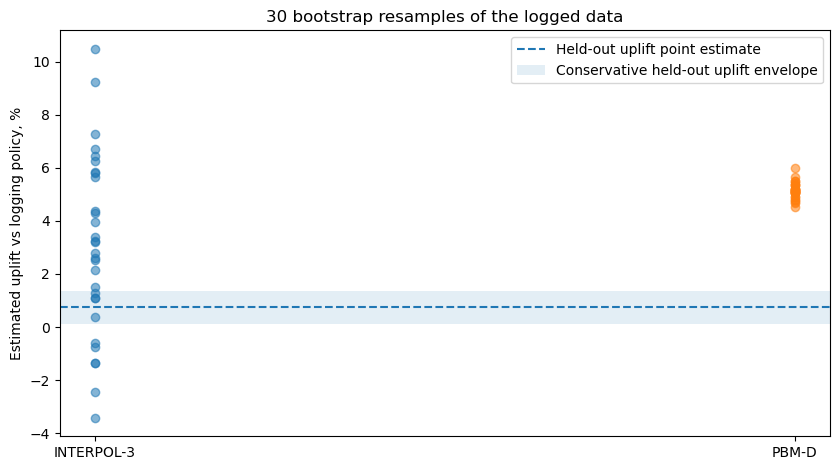

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

for estimator, g in bootstrap.groupby("estimator"):
    ax.scatter(
        np.repeat(estimator, len(g)),
        g["estimated_uplift"] * 100,
        alpha=0.55,
    )

ax.axhline(
    oracle_uplift * 100,
    linestyle="--",
    label="Held-out uplift point estimate",
)

ax.axhspan(
    oracle_uplift_lower * 100,
    oracle_uplift_upper * 100,
    alpha=0.12,
    label="Conservative held-out uplift envelope",
)

ax.set_ylabel("Estimated uplift vs logging policy, %")
ax.set_title("30 bootstrap resamples of the logged data")
ax.legend()
fig.tight_layout()
plt.show()

## 9. A/B gate

A candidate passes if estimated uplift over the logging policy clears a minimum bar.

For the held-out reference, a bar below the conservative uplift envelope is a **definite PASS**, a bar above it is a **definite FAIL**, and a bar inside the envelope is **uncertain**. Uncertain thresholds are not scored.

Two gate rules are compared: the estimator point estimate and the lower end of its reported interval. Because the benchmark contains one released target policy, the curves below are sensitivity curves for one candidate rather than population-wide error rates.


In [18]:
UPLIFT_BARS = np.array([
    0.000,
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
    0.040,
    0.050,
    0.060,
    0.080,
])


def held_out_decision_state(bar):
    if bar < oracle_uplift_lower:
        return "definite_pass"
    if bar > oracle_uplift_upper:
        return "definite_fail"
    return "uncertain"


gate_rows = []

for estimator, g in bootstrap.groupby("estimator"):
    for bar in UPLIFT_BARS:
        oracle_state = held_out_decision_state(bar)

        rules = {
            "point": (
                g["estimated_uplift"] > bar
            ),
            "lower_bound": (
                g["reported_lower_uplift"] > bar
            ),
        }

        for rule_name, predicted_pass in rules.items():
            predicted_pass = predicted_pass.to_numpy(dtype=bool)

            if oracle_state == "definite_pass":
                false_positive = np.zeros_like(
                    predicted_pass,
                    dtype=bool,
                )
                false_negative = ~predicted_pass
                mismatch = false_negative

            elif oracle_state == "definite_fail":
                false_positive = predicted_pass
                false_negative = np.zeros_like(
                    predicted_pass,
                    dtype=bool,
                )
                mismatch = false_positive

            else:
                # The held-out benchmark itself does not support a binary
                # PASS/FAIL label at this threshold.
                false_positive = np.full(
                    predicted_pass.shape,
                    False,
                    dtype=bool,
                )
                false_negative = np.full(
                    predicted_pass.shape,
                    False,
                    dtype=bool,
                )
                mismatch = None

            row = {
                "estimator": estimator,
                "gate_rule": rule_name,
                "required_uplift_pct": bar * 100,
                "held_out_uplift_point_pct": oracle_uplift * 100,
                "held_out_uplift_lower_pct": oracle_uplift_lower * 100,
                "held_out_uplift_upper_pct": oracle_uplift_upper * 100,
                "held_out_decision": oracle_state,
                "pass_rate": float(
                    predicted_pass.mean()
                ),
            }

            if mismatch is None:
                row.update({
                    "false_positive_rate": np.nan,
                    "false_negative_rate": np.nan,
                    "wrong_decision_rate": np.nan,
                })
            else:
                row.update({
                    "false_positive_rate": float(
                        np.mean(false_positive)
                    ),
                    "false_negative_rate": float(
                        np.mean(false_negative)
                    ),
                    "wrong_decision_rate": float(
                        np.mean(mismatch)
                    ),
                })

            gate_rows.append(row)


gate = pd.DataFrame(gate_rows)

display(
    gate.assign(
        pass_rate_pct=gate["pass_rate"] * 100,
        false_positive_rate_pct=gate["false_positive_rate"] * 100,
        false_negative_rate_pct=gate["false_negative_rate"] * 100,
        wrong_decision_rate_pct=gate["wrong_decision_rate"] * 100,
    )[
        [
            "estimator",
            "gate_rule",
            "required_uplift_pct",
            "held_out_decision",
            "pass_rate_pct",
            "false_positive_rate_pct",
            "false_negative_rate_pct",
            "wrong_decision_rate_pct",
        ]
    ].round(2)
)

,estimator,gate_rule,required_uplift_pct,held_out_decision,pass_rate_pct,false_positive_rate_pct,false_negative_rate_pct,wrong_decision_rate_pct
0,INTERPOL-3,point,0.0,definite_pass,80.00,0.00,20.0,20.00
1,INTERPOL-3,lower_bound,0.0,definite_pass,10.00,0.00,90.0,90.00
2,INTERPOL-3,point,0.5,uncertain,76.67,NaN,NaN,NaN
3,INTERPOL-3,lower_bound,0.5,uncertain,6.67,NaN,NaN,NaN
4,INTERPOL-3,point,1.0,uncertain,76.67,NaN,NaN,NaN
5,INTERPOL-3,lower_bound,1.0,uncertain,0.00,NaN,NaN,NaN
6,INTERPOL-3,point,1.5,definite_fail,63.33,63.33,0.0,63.33
7,INTERPOL-3,lower_bound,1.5,definite_fail,0.00,0.00,0.0,0.00
8,INTERPOL-3,point,2.0,definite_fail,63.33,63.33,0.0,63.33
9,INTERPOL-3,lower_bound,2.0,definite_fail,0.00,0.00,0.0,0.00


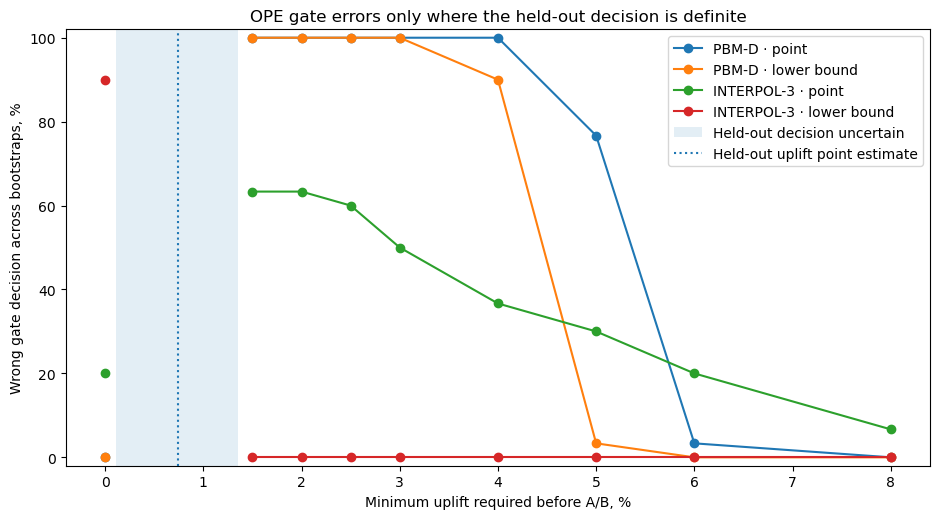

In [19]:
fig, ax = plt.subplots(figsize=(9.5, 5.3))

line_specs = [
    ("PBM-D", "point", "PBM-D · point"),
    ("PBM-D", "lower_bound", "PBM-D · lower bound"),
    ("INTERPOL-3", "point", "INTERPOL-3 · point"),
    ("INTERPOL-3", "lower_bound", "INTERPOL-3 · lower bound"),
]

for estimator, gate_rule, label in line_specs:
    g = gate[
        (gate["estimator"] == estimator)
        & (gate["gate_rule"] == gate_rule)
    ].sort_values("required_uplift_pct")

    ax.plot(
        g["required_uplift_pct"],
        g["wrong_decision_rate"] * 100,
        marker="o",
        label=label,
    )

# Gray region: the held-out data itself does not give a definite gate decision.
ax.axvspan(
    oracle_uplift_lower * 100,
    oracle_uplift_upper * 100,
    alpha=0.12,
    label="Held-out decision uncertain",
)

ax.axvline(
    oracle_uplift * 100,
    linestyle=":",
    label="Held-out uplift point estimate",
)

ax.set_xlabel("Minimum uplift required before A/B, %")
ax.set_ylabel("Wrong gate decision across bootstraps, %")
ax.set_title("OPE gate errors only where the held-out decision is definite")
ax.set_ylim(-2, 102)
ax.legend()
fig.tight_layout()
plt.show()

## 10. Result and limits

At uplift bars from **1.5% to 3%**, the held-out result is a definite FAIL. PBM-D still passes the candidate in **30/30 bootstrap resamples**, both on the point estimate and on the lower-bound rule.

At a **0%** bar, the held-out result is a definite PASS. INTERPOL-3 with the lower-bound rule rejects the candidate in **27/30 resamples**.

The exact rates are descriptive for this case. The benchmark exposes one target policy, the analysis uses 250k / 200k random subsamples rather than the full splits, and the 30 bootstrap runs are resamples of the same logged data rather than independent experiments. The uplift range is a conservative envelope of benchmark-reported intervals, not a newly calibrated joint confidence interval.


In [ ]:
RESULTS_DIR = Path("./results").resolve()
RESULTS_DIR.mkdir(exist_ok=True)

sampling_audit.to_csv(
    RESULTS_DIR / "sampling_audit.csv",
    index=False,
)

ci_audit.to_csv(
    RESULTS_DIR / "ci_source_audit.csv",
    index=False,
)

policy_value_summary.to_csv(
    RESULTS_DIR / "policy_value_and_uplift_envelope.csv",
    index=False,
)

baseline.to_csv(
    RESULTS_DIR / "baseline_estimators.csv",
    index=False,
)

slices.to_csv(
    RESULTS_DIR / "matched_slice_results.csv",
    index=False,
)

bootstrap.to_csv(
    RESULTS_DIR / "bootstrap_30_with_uplift.csv",
    index=False,
)

bootstrap_summary.to_csv(
    RESULTS_DIR / "bootstrap_30_summary.csv",
    index=False,
)

gate.to_csv(
    RESULTS_DIR / "uncertainty_aware_uplift_gate.csv",
    index=False,
)

print("Saved:")
for p in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", p)